# Correlation-Informed Quantum Learning

In [1]:
from pathlib import Path
from pprint import pprint
import sys

repository_root = next(
    (path for path in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (path / "pyproject.toml").is_file()),None,)
if repository_root is None:
    raise RuntimeError("Repository root not found: start JupyterLab inside the project")
source_directory = repository_root / "src"
if str(source_directory) not in sys.path:
    sys.path.insert(0, str(source_directory))

import corr_inf_quant_learning as ciql
from corr_inf_quant_learning import SimulationConfig, run_benchmark
from corr_inf_quant_learning.plotting import plot_benchmark

EXPECTED_METHODS = ("CS", "CorInf", "CS-AGHDO", "CorInf-AGHDO")
print(f"Using package: {Path(ciql.__file__).resolve()}")

#state and target property
N_QUBITS = 100
K_ROTATIONS = 50
SUBSYSTEM_SIZE = 7       #used only for PURITY
PROPERTY = "MAGIC"       #"PURITY" or "MAGIC"
METHODS = ("CS-AGHDO","CorInf-AGHDO")
#METHODS = ("CS","CorInf")

#measurement budget and averaging
PILOT_SHOTS = 0
POST_SHOTS = 10000
REPETITIONS = 20
EVALUATION_POINTS = 9
SEED = 7
COUNT_PILOT_COST = True

#correlation-informed acquisition and scalable estimators
CORINF_EXPLORATION = 0.001       #eta: uniform share of q_t
CORINF_COMMUTING_BIAS = 1     #PURITY softmax: >1 favors commuting
CORINF_SOFTMAX_TEMPERATURE = 0.01  # PURITY and MAGIC softmax: tau (->0 argmax, ->inf uniform over candidates)
CORINF_PAULI_FLOOR = 0.0        #PURITY softmax: coverage weight floor for every P_A
CORINF_PURITY_WEIGHT = 1.0      #PURITY: lambda_purity
CORINF_GENERATOR_WEIGHT = 1   #PURITY: lambda_gen, online generator-learning reward
CORINF_UPDATE_EVERY = 1         #PURITY: recompute q_t every this many shots
CORINF_CLIP_BOUND = "POINT"
CORINF_CANDIDATES = 100         #MAGIC: candidates scored per shot
AGHDO_FIT_STEPS = 12
QNS_PROPERTY_SAMPLES = 4096

#progress bar
PROGRESS_DETAILS = False

# Figure controls
ERROR_MODE = "relative"   #"absolute" or "relative"
LOG_X = False
LOG_Y = True
SMOOTH_WINDOW = 1
SHOW_ERROR_BAND = True


Using package: C:\Users\tedde\OneDrive\UNIVERSITY\POLITECNICO\MSC\ERHS\corr-inf-quant-learning\src\corr_inf_quant_learning\__init__.py


In [2]:
config = SimulationConfig(
    n_qubits=N_QUBITS,
    k_rotations=K_ROTATIONS,
    subsystem_size=SUBSYSTEM_SIZE,
    property=PROPERTY,
    methods=METHODS,
    pilot_shots=PILOT_SHOTS,
    post_shots=POST_SHOTS,
    repetitions=REPETITIONS,
    evaluation_points=EVALUATION_POINTS,
    seed=SEED,
    count_pilot_cost=COUNT_PILOT_COST,
    corinf_exploration=CORINF_EXPLORATION,
    corinf_commuting_bias=CORINF_COMMUTING_BIAS,
    corinf_candidates=CORINF_CANDIDATES,
    corinf_purity_weight=CORINF_PURITY_WEIGHT,
    corinf_generator_weight=CORINF_GENERATOR_WEIGHT,
    corinf_softmax_temperature=CORINF_SOFTMAX_TEMPERATURE,
    corinf_pauli_floor=CORINF_PAULI_FLOOR,
    corinf_update_every=CORINF_UPDATE_EVERY,
    corinf_clip_bound=CORINF_CLIP_BOUND,
    aghdo_fit_steps=AGHDO_FIT_STEPS,
    qns_property_samples=QNS_PROPERTY_SAMPLES,
    progress_details=PROGRESS_DETAILS,
)

result = run_benchmark(config)
print(f"Exact {PROPERTY.lower()}: {result.truth:.8g}")
print(f"Subsystem: {result.subsystem}")
print(f"Pilot cost: {result.pilot_cost} shots")
pprint(result.final_summary(ERROR_MODE))


MAGIC exact=20.75:   0%|          | 0/400000 [00:00<?, ?shot/s]

Exact magic: 20.751875
Subsystem: (55, 45, 54, 56, 65, 35, 44)
Pilot cost: 0 shots
[{'estimate_mean': 19.323883688329758,
  'estimate_sem': 0.13153932470572033,
  'method': 'CS-AGHDO',
  'relative_error_mean': 0.06881263876607113},
 {'estimate_mean': 20.604420285076213,
  'estimate_sem': 0.060469381658265285,
  'method': 'CorInf-AGHDO',
  'relative_error_mean': 0.011698612962905156}]


Saved:
  C:\Users\tedde\OneDrive\UNIVERSITY\POLITECNICO\MSC\ERHS\corr-inf-quant-learning\figures\cluster_magic_relative.pdf
  C:\Users\tedde\OneDrive\UNIVERSITY\POLITECNICO\MSC\ERHS\corr-inf-quant-learning\figures\cluster_magic_relative.png


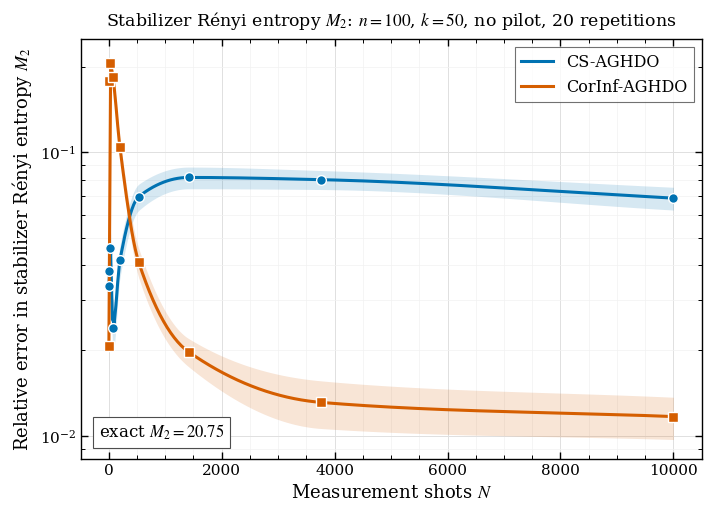

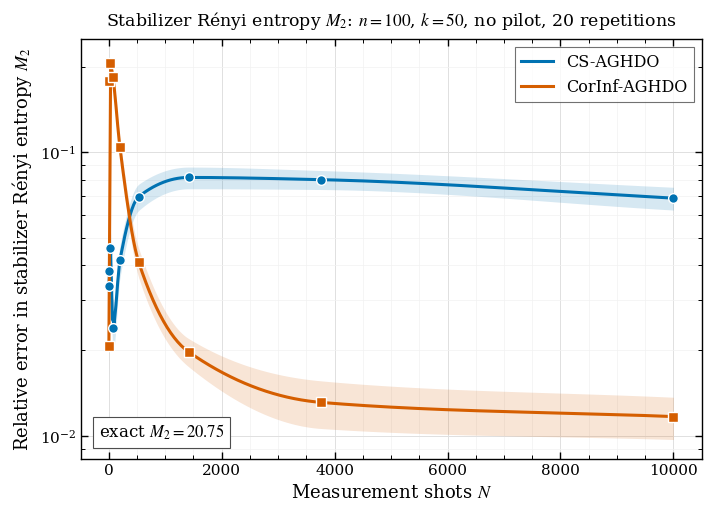

In [3]:
output_stem = repository_root / "figures" / f"cluster_{PROPERTY.lower()}_{ERROR_MODE}"
figure, axis, saved_files = plot_benchmark(
    result,
    error_mode=ERROR_MODE,
    log_x=LOG_X,
    log_y=LOG_Y,
    smooth_window=SMOOTH_WINDOW,
    show_band=SHOW_ERROR_BAND,
    output_stem=output_stem,
)
print("Saved:", *(str(path) for path in saved_files), sep="\n  " )
figure